In [17]:
from ftnode.node import (FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,)
import numpy as np
from sklearn.cluster import KMeans
from scipy.optimize import root as sp_root, least_squares
from scipy.integrate import solve_ivp as sp_solve_ivp
import torch
import pickle
device='cpu'

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from tqdm.auto import tqdm

In [2]:
f = FeluSigmoidMLP(dims=[2,20,20,20,2],lower_bound=-1, upper_bound=-0.1)
g = GeluSigmoidMLP(dims=[4,20,20,20,2],lower_bound=0, upper_bound=1)
model = FTNODE(f,g).to(device)

model_path = "../best_model-20-20-20.pth"

model.load_state_dict(torch.load(model_path))

g = model.g
g.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=4, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [3]:
xlin = np.linspace(0,1,501)
X1s, X2s = np.meshgrid(xlin,xlin)
X12s = np.vstack((X1s.flatten(), X2s.flatten())).T
X12s = torch.tensor(X12s,dtype=torch.float32)


n_control_values = 501
p_vals = np.linspace(0,1,n_control_values)
v_vals = np.linspace(0,1,n_control_values)


Z1_model = np.zeros(shape = (n_control_values,n_control_values))
Z2_model = np.zeros(shape=(n_control_values,n_control_values))

for i, pi in enumerate(tqdm(p_vals)):
    for j, vj in enumerate(v_vals):

        def objective(x):
            x_torch = torch.tensor(x,dtype=torch.float32)
            u_torch = torch.tensor([pi,vj],dtype=torch.float32)
            with torch.no_grad():
                g_out = g(x_torch,u_torch)
            diff = x_torch - g_out
            return diff.numpy()

        U = torch.tensor([[pi,vj]],dtype=torch.float32).expand(X12s.shape)
        
        with torch.no_grad():
            err = torch.linalg.norm(X12s  - g(X12s,U),axis=1)**2

        percent_cutoff = 5
        thresh = np.percentile(err, percent_cutoff)

        canidate_indices = np.where(err< thresh)

        n_guesses = 10
        kmeans = KMeans(n_clusters=n_guesses,random_state=67)
        kmeans.fit(X12s[canidate_indices].numpy())

        initial_guesses = kmeans.cluster_centers_

        roots = []
        failed_mins = []
        for guess in initial_guesses:
            sol = sp_root(objective,guess)
            if sol.success:
                roots.append(sol.x)
            else:
                failed_mins.append(sol.x)
        roots = np.array(roots)

        unique_roots = []

        for r in roots:
            # If this root is not close to any root we've already saved
            if not any(np.allclose(r, existing, atol=1e-8) for existing in unique_roots):
                unique_roots.append(r)
        
        if len(unique_roots) == 1:
            final_root = unique_roots[0]
        elif len(unique_roots) > 1:
            final_root = np.mean(unique_roots,axis=0)
        else:
            # final_root = np.mean(failed_mins,axis=0)
            print(f"No root found. p = {pi}, v = {vj} ")
        
        Z1_model[i,j] = final_root[0]
        Z2_model[i,j] = final_root[1]





  0%|          | 0/501 [00:00<?, ?it/s]

No root found. p = 0.004, v = 0.742 
No root found. p = 0.01, v = 0.936 
No root found. p = 0.038, v = 0.862 
No root found. p = 0.06, v = 0.67 
No root found. p = 0.48, v = 0.07 
No root found. p = 0.488, v = 0.08600000000000001 
No root found. p = 0.488, v = 0.11 
No root found. p = 0.492, v = 0.112 
No root found. p = 0.496, v = 0.194 
No root found. p = 0.496, v = 0.202 
No root found. p = 0.498, v = 0.122 
No root found. p = 0.498, v = 0.202 
No root found. p = 0.5, v = 0.186 
No root found. p = 0.5, v = 0.2 
No root found. p = 0.506, v = 0.166 
No root found. p = 0.506, v = 0.262 
No root found. p = 0.508, v = 0.166 
No root found. p = 0.508, v = 0.196 
No root found. p = 0.508, v = 0.254 
No root found. p = 0.51, v = 0.23800000000000002 
No root found. p = 0.51, v = 0.276 
No root found. p = 0.514, v = 0.272 
No root found. p = 0.518, v = 0.202 
No root found. p = 0.518, v = 0.23800000000000002 
No root found. p = 0.52, v = 0.198 
No root found. p = 0.52, v = 0.20800000000000002

In [15]:
save_path = "x-g_roots.pkl"

with open(save_path, 'wb') as file:
    pickle.dump(
        {"Z1": Z1_model,"Z2":Z2_model},
        file
    )

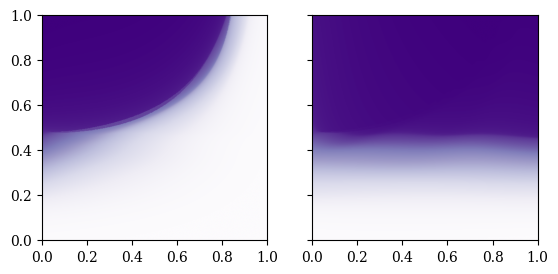

In [16]:
fig, axs = plt.subplots(1,2,sharey=True)
axs = axs.flatten()

i = 0
ax = axs[i]
ax.imshow(Z1_model,origin='lower',extent=[v_vals[0],v_vals[-1],p_vals[0],p_vals[-1]],cmap="Purples")

i=1
ax = axs[i]
ax.imshow(Z2_model,origin='lower',extent=[v_vals[0],v_vals[-1],p_vals[0],p_vals[-1]],cmap="Purples")
plt.show()

In [ ]:
## Define system 
gamma = 50
def sigmoid(x,gamma=gamma):
    return 1 / (1+np.exp(-gamma*x))

eps = 0.02
q1, q2 = (0.08, 0.04)
b1 = 1-eps
b2 = 1-eps

def c1_in(x):
    return q1*(1-sigmoid(x-b1))

def c2_in(y):
    return q1*(1-sigmoid(y-b2))

def c1_out(y):
    return q2*(1-sigmoid(y-b2))

def c2_out(y):
    return q2


def steady_state_residuals(x, p, v):
    x1, x2 = x
    
    dx1 = c1_in(x1)*(1-v)*p - c1_out(x2)*np.sqrt(x1)
    dx2 = c2_in(x2)*v*p + c1_out(x2)*np.sqrt(x1) - q2*np.sqrt(x2)
    
    return [dx1, dx2]


p_vals = np.linspace(0,1,501)
v_vals = np.linspace(0,1,501)
p_train = p_vals[10:-10:10]
v_train = v_vals[10:-10:10]

In [ ]:
Z1_true = np.zeros((len(p_vals),len(v_vals)))
Z2_true = np.zeros((len(p_vals),len(v_vals)))

x0 = [0.5,0.5]
for i, pi in enumerate(tqdm(p_vals)):
    for j, vj in enumerate(v_vals):
        
        res = least_squares(
            steady_state_residuals, 
            x0=x0, 
            args=(pi, vj), 
            bounds=([0, 0], [np.inf, np.inf]), 
            ftol=1e-4 
        )
        
        sol = res.x
        Z1_true[i, j] = sol[0]
        Z2_true[i, j] = sol[1]
        
        x0 = sol


  0%|          | 0/501 [00:00<?, ?it/s]

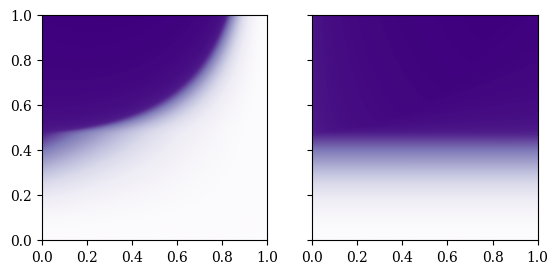

In [23]:
fig, axs = plt.subplots(1,2,sharey=True)
axs = axs.flatten()

i = 0
ax = axs[i]
ax.imshow(Z1_true,origin='lower',extent=[v_vals[0],v_vals[-1],p_vals[0],p_vals[-1]],cmap="Purples")

i=1
ax = axs[i]
ax.imshow(Z2_true,origin='lower',extent=[v_vals[0],v_vals[-1],p_vals[0],p_vals[-1]],cmap="Purples")
plt.show()

In [24]:
Z1_err = np.abs(Z1_true - Z1_model)
Z2_err = np.abs(Z2_true - Z2_model)

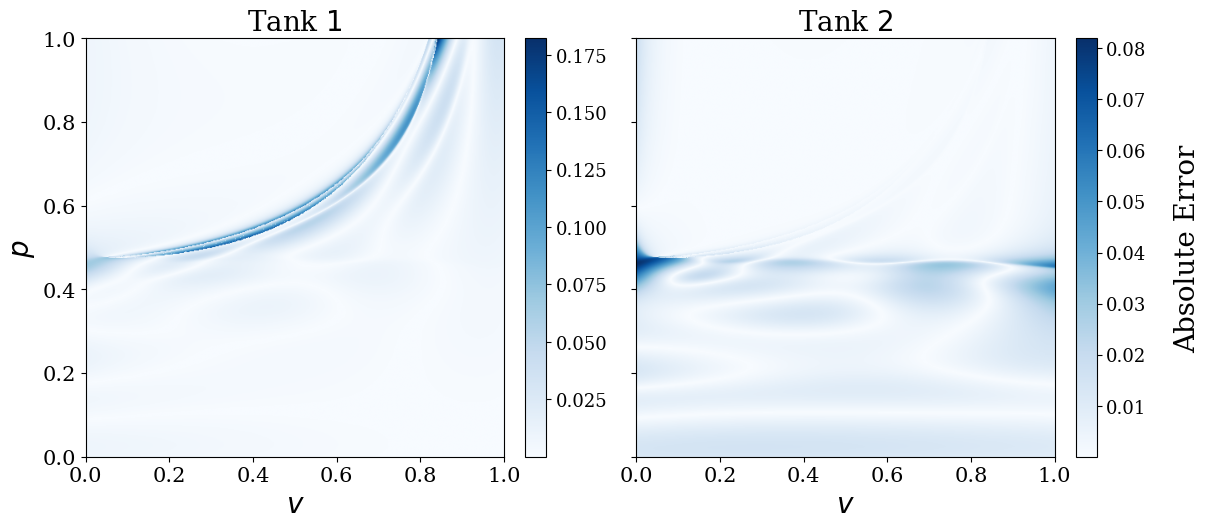

In [ ]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6), constrained_layout=True)


im1 = axs[0].imshow(Z1_err, origin='lower', 
                    extent=[v_vals[0], v_vals[-1], p_vals[0], p_vals[-1]], 
                    cmap="Blues") 

axs[0].set_xlabel(r"$v$", fontsize=20)
axs[0].set_ylabel(r"$p$", fontsize=20)
axs[0].set_title(r"Tank $1$", fontsize=20)
axs[0].tick_params(axis='both', which='major', labelsize=15)


cbar1 = fig.colorbar(im1, ax=axs[0], orientation='vertical', fraction=0.05, pad=0.01)
cbar1.ax.tick_params(labelsize=13)


im2 = axs[1].imshow(Z2_err, origin='lower', 
                    extent=[v_vals[0], v_vals[-1], p_vals[0], p_vals[-1]], 
                    cmap="Blues") 

axs[1].set_xlabel(r"$v$", fontsize=20)
axs[1].set_title(r"Tank $2$", fontsize=20)
axs[1].tick_params(axis='both', which='major', labelsize=15)

cbar2 = fig.colorbar(im2, ax=axs[1], orientation='vertical', fraction=0.05, pad=0.01)
cbar2.set_label('Absolute Error', fontsize=20,labelpad=20)
cbar2.ax.tick_params(labelsize=13)

plt.savefig("mixing-tanks-g-err.png")
plt.show()